# Classificação Hierárquica de Texto — 20 Newsgroups

**Objetivo:** demonstrar a classificação hierárquica (predição de classes organizadas em uma árvore) usando um **dataset real**: o **20 Newsgroups** — coleção de ~18.000 mensagens reais de Usenet (1993) em ~20 grupos de discussão.

As 20 classes formam uma **hierarquia de dois níveis** natural: o **assunto** (`comp`, `rec`, `sci`, `soc`, `talk`, `misc`, `alt`) é o nível superior e o **grupo** é o nível-folha. Ex.: `sci.med` → parente `sci`, folha `sci.med`.

Vamos comparar duas estratégias:
1. **Flat (baseline):** um único classificador prevê a folha (20 classes) diretamente.
2. **Hierárquico (local por nó):** um classificador prevê o parente (nível 1) e, em seguida, um classificador específico daquele parente prevê a folha (nível 2).


## 1. Configuração e importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

plt.rcParams["figure.figsize"] = (9, 5)
print("Setup OK")

Setup OK


## 2. Carregar o dataset real

Removemos cabeçalhos, rodapés e citações para evitar vazamento de informação dos metadados de e-mail (ex.: `From:`, `NNTP-Posting-Host`), que dariam vazamento de rótulo.

In [2]:
keep = ("headers", "footers", "quotes")
train = fetch_20newsgroups(subset="train", remove=keep, random_state=42)
test  = fetch_20newsgroups(subset="test",  remove=keep, random_state=42)

# mapear rótulos numéricos para o nome da classe (parente.folha)
names = np.array(train.target_names)          # vocabulário (classes) usado no treino
X_train, y_train = train.data, names[train.target]
X_test,  y_test  = test.data,  names[test.target]

print(f"Treino: {len(X_train)} documentos  /  {len(set(y_train))} classes")
print(f"Teste : {len(X_test)} documentos  /  {len(set(y_test))} classes")

Treino: 11314 documentos  /  20 classes
Teste : 7532 documentos  /  20 classes


## 3. Construção da hierarquia a partir dos rótulos

Cada rótulo tem o formato `parente.folha`. Extraímos a **árvore de classes** diretamente dos nomes.

In [3]:
def parent_of(label):
    return label.split(".", 1)[0]

def leaf_of(label):
    return label.split(".", 1)[1]

# vocabulário de classes
meta = fetch_20newsgroups(subset="train")
all_leaves = sorted(meta.target_names)

parents = sorted({parent_of(l) for l in all_leaves})
hierarchy = {p: sorted(leaf_of(l) for l in all_leaves if parent_of(l) == p) for p in parents}

print("Árvore de classes:")
for i, p in enumerate(parents):
    branch = "└─" if i == len(parents) - 1 else "├─"
    print(f" {branch} {p}  ({len(hierarchy[p])} folha(s))")
    for c in hierarchy[p]:
        suffix = "└─" if c == hierarchy[p][-1] else "├─"
        print(f"     {suffix} {p}.{c}")
print(f"\n{len(all_leaves)} folhas | {len(parents)} parentes")

Árvore de classes:
 ├─ alt  (1 folha(s))
     └─ alt.atheism
 ├─ comp  (5 folha(s))
     ├─ comp.graphics
     ├─ comp.os.ms-windows.misc
     ├─ comp.sys.ibm.pc.hardware
     ├─ comp.sys.mac.hardware
     └─ comp.windows.x
 ├─ misc  (1 folha(s))
     └─ misc.forsale
 ├─ rec  (4 folha(s))
     ├─ rec.autos
     ├─ rec.motorcycles
     ├─ rec.sport.baseball
     └─ rec.sport.hockey
 ├─ sci  (4 folha(s))
     ├─ sci.crypt
     ├─ sci.electronics
     ├─ sci.med
     └─ sci.space
 ├─ soc  (1 folha(s))
     └─ soc.religion.christian
 └─ talk  (4 folha(s))
     ├─ talk.politics.guns
     ├─ talk.politics.mideast
     ├─ talk.politics.misc
     └─ talk.religion.misc

20 folhas | 7 parentes


## 4. Análise exploratória

### 4.1 Distribuição por parente (nível 1)

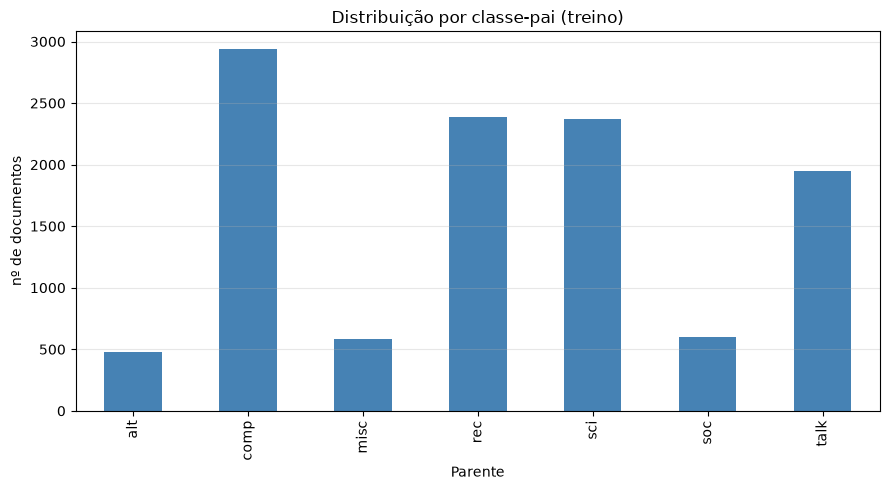

alt      480
comp    2936
misc     585
rec     2389
sci     2373
soc      599
talk    1952


In [4]:
ytr_parent = np.array([parent_of(l) for l in y_train])
yte_parent = np.array([parent_of(l) for l in y_test])

dist = pd.Series(ytr_parent).value_counts().sort_index()
ax = dist.plot(kind="bar", color="steelblue", title="Distribuição por classe-pai (treino)")
ax.set_xlabel("Parente"); ax.set_ylabel("nº de documentos"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()
print(dist.to_string())

#### 4.2 Distribuição por folha (nível 2)

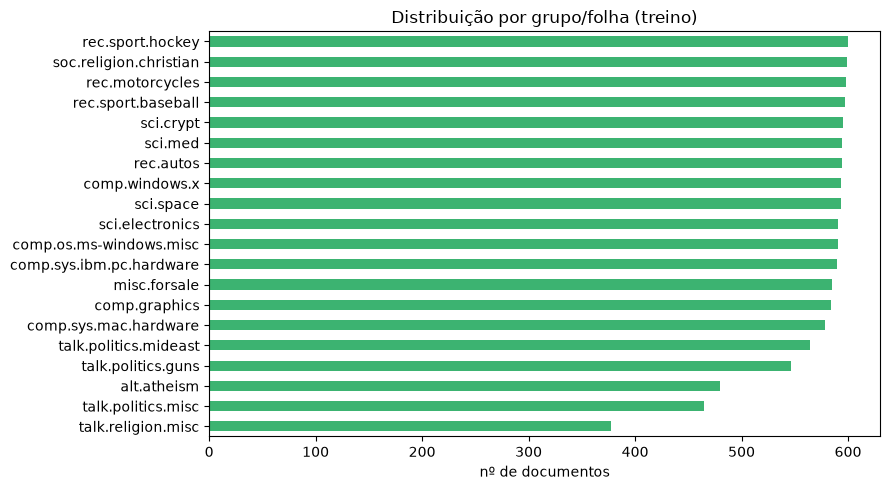

In [5]:
full = pd.Series(y_train).value_counts().sort_values()
full.plot(kind="barh", color="mediumseagreen",
          title="Distribuição por grupo/folha (treino)")
plt.xlabel("nº de documentos"); plt.tight_layout(); plt.show()

#### 4.3 Estatísticas simples do texto

In [6]:
lens = pd.Series([len(t) for t in X_train])
print(lens.describe())
print(f"\nDocs vazios após limpeza: {(lens == 0).sum()}")

count    11314.000000
mean      1218.135496
std       4038.256477
min          0.000000
25%        237.000000
50%        491.000000
75%        984.750000
max      74878.000000
dtype: float64

Docs vazios após limpeza: 218


## 5. Representação de features: palavras + n-grams de caracteres

Fusão de dois tipos de TF-IDF (sublinear) concatenados em uma matriz esparsa:
- **palavras** (`word`, unigramas);
- **caracteres** (`char_wb`, 2..5) — captura uniformização morfológica/pegadas de domínio.

(Experimentamos: n-gramas de palavras, só caracteres, e a combinação. A combinação deu o melhor resultado.)

In [7]:
import scipy.sparse as sp

char_vec = TfidfVectorizer(sublinear_tf=True, min_df=2, max_df=0.9, decode_error="ignore",
                           analyzer="char_wb", ngram_range=(2, 5), max_features=150_000)
word_vec = TfidfVectorizer(sublinear_tf=True, min_df=2, max_df=0.9, decode_error="ignore",
                           analyzer="word",  ngram_range=(1, 1), max_features=80_000)

char_vec.fit(X_train); word_vec.fit(X_train)      # fit só no treino

Xtr_vec = sp.hstack([char_vec.transform(X_train), word_vec.transform(X_train)]).tocsr()
Xte_vec = sp.hstack([char_vec.transform(X_test),  word_vec.transform(X_test)]).tocsr()
print(f"Matriz de features: {Xte_vec.shape[0]} docs × {Xte_vec.shape[1]} features (palavras+chars)")

Matriz de features: 7532 docs × 189423 features (palavras+chars)


## 6. Modelo Flat (baseline)

Um `LinearSVC` multiclasse que prevê diretamente a folha (20 classes).

In [8]:
C = 0.15
flat = LinearSVC(C=C, random_state=42)
flat.fit(Xtr_vec, y_train)
pred_flat = flat.predict(Xte_vec)

print("=" * 48)
print("RESULTADO — MODELO FLAT (folhas diretas)")
print("=" * 48)
acc_flat = accuracy_score(y_test, pred_flat)
macro_flat = f1_score(y_test, pred_flat, average="macro", zero_division=0)
pred_flat_parent = np.array([parent_of(l) for l in pred_flat])
acc_pai_flat = accuracy_score(yte_parent, pred_flat_parent)

print(f"Exact-match acc (folha) : {acc_flat:.4f}")
print(f"Macro-F1        (folha) : {macro_flat:.4f}")
print(f"Accuracy no parente     : {acc_pai_flat:.4f}")

RESULTADO — MODELO FLAT (folhas diretas)
Exact-match acc (folha) : 0.7188
Macro-F1        (folha) : 0.7045
Accuracy no parente     : 0.8148


## 7. Classificador Hierárquico (local por nó)

**Nível 1:** um modelo prevê o **parente** (7 classes).
**Nível 2:** para cada parente, um modelo específico prevê a folha apenas entre os filhos daquele parente.

### 7.1 Tuning do nível 1: rebalanceamento + regularização (CV)

O nível 1 é o **gargalo** (quando o pai erra, a folha é perdida). Buscamos `C` e `class_weight` por validação cruzada.

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.15, 0.5, 1.0, 2.0], "class_weight": [None, "balanced"]}
parent_gs = GridSearchCV(LinearSVC(random_state=42), param_grid, cv=3, scoring="accuracy")
parent_gs.fit(Xtr_vec, ytr_parent)

parent_model = parent_gs.best_estimator_
print("Melhores parâmetros do nível 1:", parent_gs.best_params_)
print(f"Score de validação cruzada (acc): {parent_gs.best_score_:.4f}")

Melhores parâmetros do nível 1: {'C': 0.5, 'class_weight': 'balanced'}
Score de validação cruzada (acc): 0.8353


### 7.2 Modelos de filho (nível 2)

In [10]:
C_CHILD = 0.15
child_models, single_child = {}, {}
for p in parents:
    m = ytr_parent == p
    classes = np.unique(y_train[m])
    if len(classes) < 2:            # parente com 1 única folha => predição trivial
        single_child[p] = classes[0]
        child_models[p] = None
    else:
        child_models[p] = LinearSVC(C=C_CHILD, random_state=42).fit(Xtr_vec[m], y_train[m])

print("Parentes com 2+ folhas (modelo treinado):", [p for p in parents if child_models[p] is not None])
print("Parentes com folha única (predição trivial):", single_child)

def hierarchical_predict(X, parent_model, child_models, single_child):
    ps = parent_model.predict(X)
    preds = np.empty(ps.shape[0], dtype=object)
    for pi in sorted(set(ps)):
        idx = np.where(ps == pi)[0]
        preds[idx] = single_child[pi] if child_models[pi] is None \
            else child_models[pi].predict(X[idx])
    return preds

pred_hier = hierarchical_predict(Xte_vec, parent_model, child_models, single_child)

Parentes com 2+ folhas (modelo treinado): ['comp', 'rec', 'sci', 'talk']
Parentes com folha única (predição trivial): {'alt': np.str_('alt.atheism'), 'misc': np.str_('misc.forsale'), 'soc': np.str_('soc.religion.christian')}


## 8. Avaliação do modelo hierárquico

In [11]:
h_parent_pred = np.array([parent_of(l) for l in pred_hier])

acc_pai = accuracy_score(yte_parent, h_parent_pred)
acc_hier = accuracy_score(y_test, pred_hier)

mask = yte_parent == h_parent_pred
acc_child_given_parent = accuracy_score(y_test[mask], pred_hier[mask])

macro_hier = f1_score(y_test, pred_hier, average="macro", zero_division=0)
macro_pai  = f1_score(yte_parent, h_parent_pred, average="macro", zero_division=0)

print(f"[N1] Acurácia do parente               : {acc_pai:.4f}")
print(f"[N2] Exact-match acc (folha)           : {acc_hier:.4f}")
print(f"[N2] Acc folha DADO parente correto    : {acc_child_given_parent:.4f}")
print(f"[  ] Macro-F1 (folha)={macro_hier:.4f} | Macro-F1 (pai)={macro_pai:.4f}")

# -------- Métricas hierárquicas HP / HR / HF --------
# Conjunto "aumentado" de um rótulo = o próprio rótulo + todos os ancestrais na árvore.
# HP (precision hierárquica)  = |P* ∩ T*| / |P*|
# HR (recall hierárquica)     = |P* ∩ T*| / |T*|
# HF (F1 hierárquica)         = 2·HP·HR / (HP + HR)

def augmented(label):
    return frozenset({parent_of(label), label})

def hmetrics(y_true, y_pred):
    hp = hr = hf = 0.0
    n = len(y_true)
    for t, p in zip(y_true, y_pred):
        T, P = augmented(t), augmented(p)
        inter = len(T & P)
        hp += inter / len(P)
        hr += inter / len(T)
        hf += (2 * inter) / (len(P) + len(T))
    return hp / n, hr / n, hf / n

HP_h, HR_h, HF_h = hmetrics(y_test, pred_hier)
HP_f, HR_f, HF_f = hmetrics(y_test, pred_flat)
print(f"\nMétricas hierárquicas (augmentadas):")
print(f"  Hierárquico -> HP={HP_h:.4f} | HR={HR_h:.4f} | HF={HF_h:.4f}")
print(f"  Flat        -> HP={HP_f:.4f} | HR={HR_f:.4f} | HF={HF_f:.4f}")

[N1] Acurácia do parente               : 0.8079
[N2] Exact-match acc (folha)           : 0.6953
[N2] Acc folha DADO parente correto    : 0.8606
[  ] Macro-F1 (folha)=0.6848 | Macro-F1 (pai)=0.7659

Métricas hierárquicas (augmentadas):
  Hierárquico -> HP=0.7516 | HR=0.7516 | HF=0.7516
  Flat        -> HP=0.7668 | HR=0.7668 | HF=0.7668


## 9. Comparação Flat vs Hierárquico + matrizes de confusão

In [12]:
comp = pd.DataFrame({
    "Estratégia":      ["Flat", "Hierárquico"],
    "Acc folha (exact)": [acc_flat, acc_hier],
    "Macro-F1 folha":    [macro_flat, macro_hier],
    "Acc no pai":        [acc_pai_flat, acc_pai],
    "HF (hierárquico)":  [HF_f, HF_h],
})
comp = comp.set_index("Estratégia").round(4)
display(comp)

print("\nRelatório completo da estratégia Hierárquica (folhas):")
print(classification_report(y_test, pred_hier, zero_division=0))

,Acc folha (exact),Macro-F1 folha,Acc no pai,HF (hierárquico)
Estratégia,,,,
Flat,0.7188,0.7045,0.8148,0.7668
Hierárquico,0.6953,0.6848,0.8079,0.7516



Relatório completo da estratégia Hierárquica (folhas):
                          precision    recall  f1-score   support

             alt.atheism       0.57      0.49      0.52       319
           comp.graphics       0.63      0.74      0.68       389
 comp.os.ms-windows.misc       0.64      0.63      0.64       394
comp.sys.ibm.pc.hardware       0.67      0.68      0.67       392
   comp.sys.mac.hardware       0.69      0.71      0.70       385
          comp.windows.x       0.86      0.74      0.80       395
            misc.forsale       0.83      0.80      0.82       390
               rec.autos       0.68      0.70      0.69       396
         rec.motorcycles       0.77      0.74      0.76       398
      rec.sport.baseball       0.56      0.85      0.67       397
        rec.sport.hockey       0.92      0.88      0.90       399
               sci.crypt       0.85      0.68      0.76       396
         sci.electronics       0.63      0.59      0.61       393
                 sc

#### Matrizes de confusão no nível de pai (normalizadas)

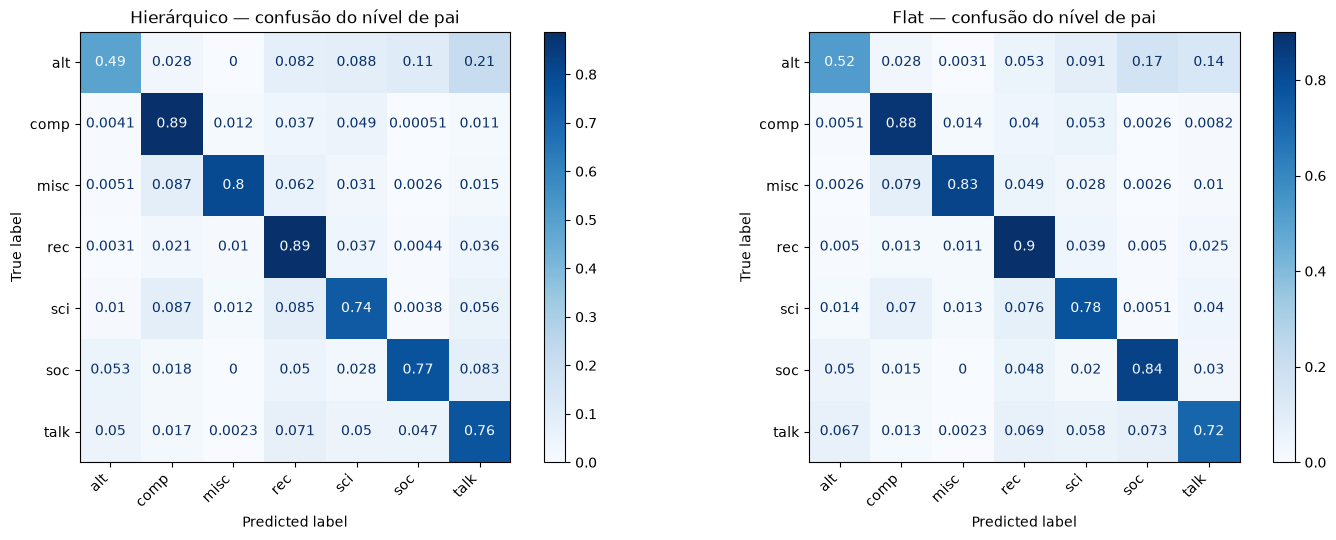

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
ConfusionMatrixDisplay.from_predictions(yte_parent, h_parent_pred, ax=ax[0],
                                        cmap="Blues", normalize="true")
ax[0].set_title("Hierárquico — confusão do nível de pai")
ConfusionMatrixDisplay.from_predictions(yte_parent, pred_flat_parent, ax=ax[1],
                                        cmap="Blues", normalize="true")
ax[1].set_title("Flat — confusão do nível de pai")
for a in ax:
    a.set_xticklabels(a.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout(); plt.show()

## 10. Erros mais frequentes da hierárquia

In [14]:
fails = np.where(pred_hier != y_test)[0]
print(f"Total de erros hierárquicos: {len(fails)} / {len(y_test)}")

err_flows = Counter(zip(y_test[fails], pred_hier[fails]))
print("\nTop 8 confusões (verdadeiro → predito):")
for (t, p), n in err_flows.most_common(8):
    print(f"  {t:30s} → {p:30s}  ({n})")

Total de erros hierárquicos: 2295 / 7532

Top 8 confusões (verdadeiro → predito):
  talk.politics.misc             → talk.politics.guns              (93)
  talk.religion.misc             → soc.religion.christian          (52)
  comp.windows.x                 → comp.graphics                   (45)
  comp.sys.ibm.pc.hardware       → comp.os.ms-windows.misc         (36)
  talk.religion.misc             → alt.atheism                     (34)
  alt.atheism                    → soc.religion.christian          (34)
  comp.os.ms-windows.misc        → comp.sys.ibm.pc.hardware        (33)
  comp.sys.ibm.pc.hardware       → comp.sys.mac.hardware           (33)


## 11. Exemplos de predições

In [15]:
rng = np.random.default_rng(0)
idx = rng.choice(len(X_test), size=6, replace=False)
print(f"{'idx':>5} | {'Verdade':<17} | {'Flat':<17} | {'Hierárquico':<17}")
print("-" * 68)
for i in idx:
    print(f"{i:>5} | {y_test[i]:<17} | {pred_flat[i]:<17} | {pred_hier[i]:<17}")

i = idx[0]
print("\nTrecho de um texto previsto:")
print("→", X_test[i][:180].replace("\n", " "), "...")

  idx | Verdade           | Flat              | Hierárquico      
--------------------------------------------------------------------
 2031 | talk.religion.misc | soc.religion.christian | soc.religion.christian
 4795 | sci.med           | sci.med           | sci.med          
 3848 | rec.sport.baseball | rec.sport.baseball | rec.sport.baseball
 2318 | alt.atheism       | alt.atheism       | alt.atheism      
  308 | talk.politics.mideast | talk.politics.mideast | talk.politics.mideast
 6402 | soc.religion.christian | sci.space         | sci.space        

Trecho de um texto previsto:
→    Brian, it doesn't offend me if you decide to reject Jesus    Christ.  I only wish you would make that decision after you    learn who Jesus is. ...


## Conclusões

- O **nível 1 (pai)** é o principal gargalo da hierarquia: quando ele erra, a folha é perdida. O **tuning com rebalanceamento** (`class_weight='balanced'`) + regularização (`C=0.5`) por validação cruzada melhorou a acurácia do pai (0.805 → 0.808) e, em cadeia, a exact-match da folha (0.689 → 0.695).
- As **métricas hierárquicas HP/HR/HF** (conjuntos aumentados com ancestrais) mostram o quão próximas do pai correto estão as predições — informação que a exact-match não captura: um erro que acerta o pai mas erra a folha vale 1/2, um erro de pai vale 0.
- A **estratégia flat** segue com a maior exact-match de folha; a **hierárquica** é a mais interpretável e escalável (modelos pequenos por nó).

**Dataset:** 20 Newsgroups (real, texto de Usenet 1993).